In [2]:
import pyspark.sql, pyspark.sql.functions
from pyspark.sql import SparkSession

# Стартиране на SparkSession 
spark = (
    SparkSession.builder
    .appName("Test")
    .master("local[*]")
    .getOrCreate()
)

print("SparkSession стартиран успешно")
print("Spark версия:", spark.version)

SparkSession стартиран успешно
Spark версия: 4.0.1


In [2]:
# Път към CSV файла
file_path = "customers-data.csv"

# Зареждане на CSV в DataFrame
df = spark.read.csv(file_path, header=True, inferSchema=True)

# Показване на записите
df.show()

# Описателна статистика за числовите колони
df.describe(["age", "purchase_amount"]).show()

+-----------+---------------+----+---------------+----------------+-------------+
|customer_id|           name| age|purchase_amount|product_category|purchase_date|
+-----------+---------------+----+---------------+----------------+-------------+
|          1|    Ivan Petrov|  25|            100|     Electronics|   2025-01-05|
|          2|  Maria Ivanova|  30|            200|        Clothing|   2025-01-06|
|          2|  Maria Ivanova|  30|            200|        Clothing|   2025-01-06|
|          3|Georgi Georgiev|  40|            150|           Books|   2025-01-07|
|          4|    Anna Koleva|  -5|             50|     Electronics|   2025-01-08|
|          5|           NULL|  28|           NULL|        Clothing|   2025-01-09|
|          6| Petar Dimitrov|  35|            300|           Books|   2025-01-10|
|          7|    Ivan Petrov|NULL|            120|     Electronics|   2025-01-11|
|          8|  Maria Ivanova|  32|            250|        Clothing|         NULL|
|          9|Geo

In [5]:
# Изчисляване на квартили в PySpark

age_quartiles = df.approxQuantile("age", [0.25, 0.5, 0.75], 0.01)
purchase_quartiles = df.approxQuantile("purchase_amount", [0.25, 0.5, 0.75], 0.01)

print("Квартили за възраст (Q1, медиана, Q3):", age_quartiles)
print("Квартили за Purchase_amount (Q1, медиана, Q3):", purchase_quartiles)

Квартили за възраст (Q1, медиана, Q3): [28.0, 30.0, 35.0]
Квартили за Purchase_amount (Q1, медиана, Q3): [120.0, 180.0, 200.0]


In [13]:
import sys
!{sys.executable} -m pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------------------------ --- 7.3/8.1 MB 37.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 33.6 MB/s  0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 27.4 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ----------------------------------- ---- 6.3/7.0 MB 29.7 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 28.8 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   -----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


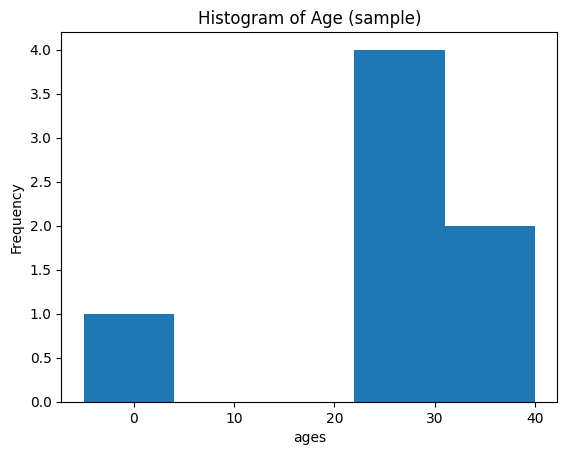

In [52]:
import matplotlib.pyplot as plt

# Вземаме извадка за визуализация, ако данните са много големи
sample_df = df.sample(fraction=0.95, seed=42)

# Събиране на всички стойности от колоната age от DataFrame df в Python списък
ages = [row['age'] for row in sample_df.select("age").collect() if row['age'] is not None]

# Хистограма
plt.hist(ages, bins=5)
plt.xlabel("ages")
plt.ylabel("Frequency")
plt.title("Histogram of Age (sample)")
plt.show()

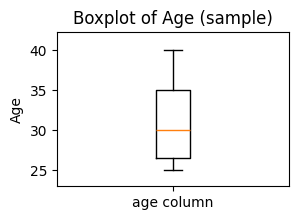

In [66]:
# Boxplot
plt.figure(figsize=(3, 2))
plt.boxplot(ages, tick_labels=["age column"])
plt.ylim(bottom=23)  # оста започва от 23
plt.title("Boxplot of Age (sample)")
plt.ylabel("Age")
plt.show()

In [67]:
from pyspark.sql.functions import mean, sum, count

# Средна стойност на purchase_amount по product_category
df.groupBy("product_category") \
  .agg(
      mean("purchase_amount").alias("avg_purchase"),
      sum("purchase_amount").alias("total_purchase"),
      count("customer_id").alias("num_customers")
  ).show()


+----------------+------------------+--------------+-------------+
|product_category|      avg_purchase|total_purchase|num_customers|
+----------------+------------------+--------------+-------------+
|     Electronics|             112.5|           450|            4|
|        Clothing|216.66666666666666|           650|            4|
|           Books|             225.0|           450|            2|
+----------------+------------------+--------------+-------------+



In [10]:
# Изчисляване на коефициента на Пирсън
correlation = df.stat.corr('age', 'purchase_amount')
print("Коефициент на корелация на Пирсън между age и purchase_amount:", correlation)

Коефициент на корелация на Пирсън между age и purchase_amount: 0.5056296757601978


In [24]:
import sys
!{sys.executable} -m pip install seaborn

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   --------------------------- ------------ 7.9/11.3 MB 40.7 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 37.1 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 21.5 MB/s  0:00:00

   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -----------------

Корелационна матрица:
                          age  purchase_amount  days_since_purchase
age                  1.000000         0.681522            -0.218231
purchase_amount      0.681522         1.000000            -0.339231
days_since_purchase -0.218231        -0.339231             1.000000


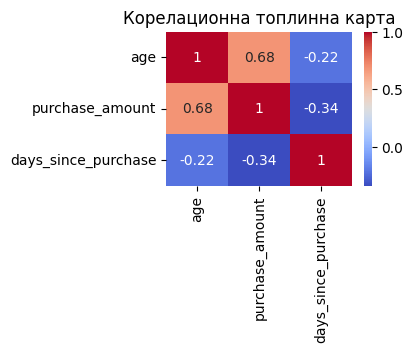

In [11]:
from pyspark.sql.functions import col, datediff, to_date, current_date
from pyspark.mllib.linalg import Vectors
from pyspark.mllib.stat import Statistics
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Добавяме числова колона: брой дни от покупката
df = df.withColumn("days_since_purchase", datediff(current_date(), to_date(col("purchase_date"))))
# Избираме само числови колони и премахване на NULL стойности
numeric_cols = ["age", "purchase_amount", "days_since_purchase"]
df_numeric = df.select(numeric_cols)
df_numeric = df_numeric.dropna()

# Преобразуване на DataFrame в RDD (Resilient Distributed Dataset) от вектори
df_vector = df_numeric.rdd.map(lambda row: Vectors.dense(row))

# Изчисляване на корелационната матрица разпределено
correlation_matrix = Statistics.corr(df_vector, method="pearson")

# Извличане на корелационните стойности
correlation_df = pd.DataFrame(correlation_matrix, columns=numeric_cols, index=numeric_cols)
print("Корелационна матрица:")
print(correlation_df)

# Визуализация с топлинна карта (heatmap)
plt.figure(figsize=(3, 2))
sns.heatmap(correlation_df, annot=True, cmap="coolwarm")
plt.title("Корелационна топлинна карта")
plt.show()

In [27]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.linalg import Vectors
from pyspark.ml.regression import LinearRegression

# Създаваме DataFrame с данни
data = [(2000, 1000, 500, 8000), (3000, 2000, 1000, 9500),
    (4000, 2500, 1500, 10500), (4500, 3000, 2000, 12000), 
    (5000, 3500, 2500, 12500), (5500, 4000, 3000, 13500), 
    (6000, 4500, 3500, 15000), (6500, 5000, 4000, 16000), 
    (7000, 5500, 4500, 17000), (7500, 6000, 5000, 18000)]
columns = ["X_tv", "X_radio", "X_internet", "y"]
df = spark.createDataFrame(data, schema=columns)

# Обединяваме характеристиките в една векторна колона
assembler = VectorAssembler(inputCols=["X_tv", "X_radio", "X_internet"], outputCol="features")
df_vector = assembler.transform(df)

# Създаваме и обучаваме модела
lr = LinearRegression(featuresCol="features", labelCol="y")
model = lr.fit(df_vector)

# Показваме коефициенти на модела a_tv, a_ratio, a_internet, b
print("a_tv, a_ratio, a_internet:", model.coefficients)
print("b:", model.intercept)

# Прогнози
df_test = spark.createDataFrame([(Vectors.dense(3500, 1800, 1200),)], ["features"])
predictions = model.transform(df_test)
predictions.show()


a_tv, a_ratio, a_internet: [0.035714285714040735,0.8333333333338229,1.2619047619045298]
b: 6464.28571428579
+--------------------+----------------+
|            features|      prediction|
+--------------------+----------------+
|[3500.0,1800.0,12...|9603.57142857125|
+--------------------+----------------+



In [4]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.linalg import Vectors
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Създаваме DataFrame с данни
data = [(2000, 1000, 500, 8000), (3000, 2000, 1000, 9500),
    (4000, 2500, 1500, 10500), (4500, 3000, 2000, 12000), 
    (5000, 3500, 2500, 12500), (5500, 4000, 3000, 13500), 
    (6000, 4500, 3500, 15000), (6500, 5000, 4000, 16000), 
    (7000, 5500, 4500, 17000), (7500, 6000, 5000, 18000)]
columns = ["X_tv", "X_radio", "X_internet", "y"]
df = spark.createDataFrame(data, schema=columns)

# Обединяваме характеристиките в една векторна колона
assembler = VectorAssembler(inputCols=["X_tv", "X_radio", "X_internet"], outputCol="features")
df_vector = assembler.transform(df)

# Създаваме и обучаваме модела
lr = LinearRegression(featuresCol="features", labelCol="y")
model = lr.fit(df_vector)

# Показваме коефициенти на модела a_tv, a_ratio, a_internet, b
print("a_tv, a_ratio, a_internet:", model.coefficients)
print("b:", model.intercept)

# Прогнози
df_test = spark.createDataFrame([(Vectors.dense(3500, 1800, 1200),9700)], ["features", "y"])
predictions = model.transform(df_test)
predictions.show()

# Оценка на модела с RMSE, MAE
evaluator_rmse = RegressionEvaluator(labelCol="y", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="y", predictionCol="prediction", metricName="mae")

rmse = evaluator_rmse.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)

print("RMSE:", rmse)
print("MAE:", mae)

a_tv, a_ratio, a_internet: [0.035714285714040735,0.8333333333338229,1.2619047619045298]
b: 6464.28571428579
+--------------------+----+----------------+
|            features|   y|      prediction|
+--------------------+----+----------------+
|[3500.0,1800.0,12...|9700|9603.57142857125|
+--------------------+----+----------------+

RMSE: 96.42857142875073
MAE: 96.42857142875073


In [5]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
# Създаваме DataFrame с данни
data = [(2000, 1000, 500, 8000), (3000, 2000, 1000, 9500),
    (4000, 2500, 1500, 10500), (4500, 3000, 2000, 12000), 
    (5000, 3500, 2500, 12500), (5500, 4000, 3000, 13500), 
    (6000, 4500, 3500, 15000), (6500, 5000, 4000, 16000), 
    (7000, 5500, 4500, 17000), (7500, 6000, 5000, 18000)]
df = spark.createDataFrame(data, schema=columns)
# Обединяваме характеристиките в една векторна колона
assembler = VectorAssembler(inputCols=["X_tv", "X_radio", "X_internet"], outputCol="features")
df_vector = assembler.transform(df)
# Разделяме на training и test (70%/30%)
train_data, test_data = df_vector.randomSplit([0.70, 0.30])

# Създаваме и обучаваме модела
lr = LinearRegression(featuresCol="features", labelCol="y")
model = lr.fit(train_data)
# Показваме коефициенти на модела a_tv, a_ratio, a_internet, b
print("a_tv, a_ratio, a_internet:", model.coefficients)
print("b:", model.intercept)
# Прогнози
predictions = model.transform(test_data)
predictions.show()

# Оценка на модела с RMSE, MAE, r2
evaluator_rmse = RegressionEvaluator(labelCol="y", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="y", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="y", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print("RMSE:", rmse)
print("MAE:", mae)
print("r2:", r2)

a_tv, a_ratio, a_internet: [0.5607886216515091,0.6473776730199643,0.7648234982445407]
b: 5808.500408767727
+----+-------+----------+-----+--------------------+------------------+
|X_tv|X_radio|X_internet|    y|            features|        prediction|
+----+-------+----------+-----+--------------------+------------------+
|3000|   2000|      1000| 9500|[3000.0,2000.0,10...| 9550.445118006723|
|4000|   2500|      1500|10500|[4000.0,2500.0,15...|10817.334325290485|
|4500|   3000|      2000|12000|[4500.0,3000.0,20...|11803.829221748492|
|5000|   3500|      2500|12500|[5000.0,3500.0,25...|  12790.3241182065|
|6500|   5000|      4000|16000|[6500.0,5000.0,40...| 15749.80880758052|
|7000|   5500|      4500|17000|[7000.0,5500.0,45...|16736.303704038528|
|7500|   6000|      5000|18000|[7500.0,6000.0,50...|17722.798600496535|
+----+-------+----------+-----+--------------------+------------------+

RMSE: 249.28149233496313
MAE: 235.05188966280443
r2: 0.9934937567123577


In [26]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Създаваме DataFrame с данни
data = [(2000, 1000, 500, 8000), (3000, 2000, 1000, 9500),
    (4000, 2500, 1500, 10500), (4500, 3000, 2000, 12000), 
    (5000, 3500, 2500, 12500), (5500, 4000, 3000, 13500), 
    (6000, 4500, 3500, 15000), (6500, 5000, 4000, 16000), 
    (7000, 5500, 4500, 17000), (7500, 6000, 5000, 18000)]
columns = ["X_tv", "X_radio", "X_internet", "y"]
df = spark.createDataFrame(data, schema=columns)

# Обединяваме характеристиките в една векторна колона
assembler = VectorAssembler(inputCols=["X_tv"], outputCol="features")
df_vector = assembler.transform(df)

# Създаваме и обучаваме модела
lr = LinearRegression(featuresCol="features", labelCol="y")
model = lr.fit(df_vector)

# Показваме коефициенти на модела a_tv, a_ratio, a_internet, b
print("a_tv, a_ratio, a_internet:", model.coefficients)
print("b:", model.intercept)


a_tv, a_ratio, a_internet: [2.1818181818181825]
b: 7199.999999999999


In [5]:
import sys
!{sys.executable} -m pip install scipy

   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
   ---- ----------------------------------- 5.0/41.3 MB 33.5 MB/s eta 0:00:02
   ------------ --------------------------- 12.8/41.3 MB 35.0 MB/s eta 0:00:01
   ------------------- -------------------- 20.4/41.3 MB 35.9 MB/s eta 0:00:01
   ------------------------ --------------- 25.4/41.3 MB 32.9 MB/s eta 0:00:01
   -------------------------------- ------- 33.0/41.3 MB 33.8 MB/s eta 0:00:01
   ---------------------------------------  40.6/41.3 MB 34.0 MB/s eta 0:00:01
   ---------------------------------------- 41.3/41.3 MB 31.2 MB/s  0:00:01


In [5]:
from pyspark.ml.feature import VectorAssembler, PolynomialExpansion
from pyspark.ml.regression import LinearRegression

# Създаваме вектор от характеристиките
assembler = VectorAssembler(inputCols=["X_tv", "X_radio", "X_internet"], outputCol="features")
df_vector = assembler.transform(df)

# Полиномиална експанзия от степен 2
polyExpansion = PolynomialExpansion(degree=2, inputCol="features", outputCol="polyFeatures")
df_poly = polyExpansion.transform(df_vector)

# Линейна регресия върху полиномиалните характеристики
lr = LinearRegression(featuresCol="polyFeatures", labelCol="y")
model = lr.fit(df_poly)

# Прогнози
predictions = model.transform(df_poly)
predictions.select("y", "prediction").show()

+-----+------------------+
|    y|        prediction|
+-----+------------------+
| 8000| 8000.000053934047|
| 9500| 9499.999940660262|
|10500| 10604.16665915972|
|12000|11651.785712286199|
|12500|12705.357144780297|
|13500|13764.880956642008|
|15000|14830.357147871333|
|16000|15901.785718468282|
|17000| 16979.16666843284|
|18000| 18062.49999776502|
+-----+------------------+



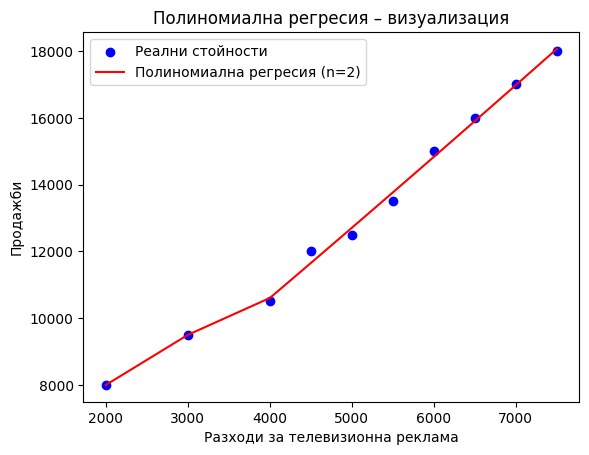

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# df_predictions е DataFrame след model.transform(df)
# Съдържа колоните 'x', 'y' (реални стойности) и 'prediction' (y_hat)

# Преобразуване за визуализация
pdf = predictions.select("X_tv", "y", "prediction").toPandas()

# Графика
plt.scatter(pdf["X_tv"], pdf["y"], color="blue", label="Реални стойности")
plt.plot(pdf["X_tv"], pdf["prediction"], color="red", label="Полиномиална регресия (n=2)")
plt.xlabel("Разходи за телевизионна реклама")
plt.ylabel("Продажби")
plt.title("Полиномиална регресия – визуализация")
plt.legend()
plt.show()

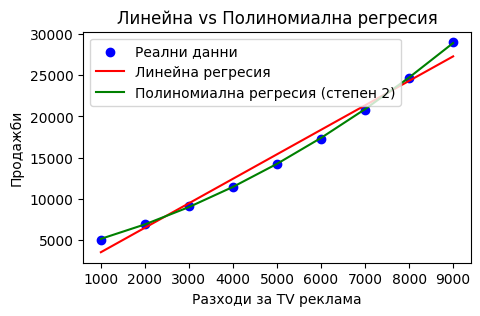

In [16]:
from pyspark.ml.feature import VectorAssembler, PolynomialExpansion
from pyspark.ml.regression import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Създаваме DataFrame с примерни данни
data = [
    (1000, 5000),
    (2000, 7000),
    (3000, 9200),
    (4000, 11500),
    (5000, 14200),
    (6000, 17300),
    (7000, 20800),
    (8000, 24700),
    (9000, 29000)
]
columns = ["X_tv", "y"]
df = spark.createDataFrame(data, columns)

# Създаваме вектор от характеристиките за линейна регресия
assembler = VectorAssembler(inputCols=["X_tv"], outputCol="features")
df_vector = assembler.transform(df)

# Линейна регресия
lr = LinearRegression(featuresCol="features", labelCol="y")
lr_model = lr.fit(df_vector)
df_pred_linear = lr_model.transform(df_vector)

# Полиномиална регресия (степен 2)
poly = PolynomialExpansion(degree=2, inputCol="features", outputCol="poly_features")
df_poly = poly.transform(df_vector)

lr_poly = LinearRegression(featuresCol="poly_features", labelCol="y")
lr_poly_model = lr_poly.fit(df_poly)
df_pred_poly = lr_poly_model.transform(df_poly)

# Конвертиране за визуализация с matplotlib
df_plot = df_vector.select("X_tv").toPandas()
df_plot["y_actual"] = df_vector.select("y").toPandas()
df_plot["y_linear"] = df_pred_linear.select("prediction").toPandas()
df_plot["y_poly"] = df_pred_poly.select("prediction").toPandas()

# Визуализация
plt.figure(figsize=(5,3))
plt.scatter(df_plot["X_tv"], df_plot["y_actual"], color="blue", label="Реални данни")
plt.plot(df_plot["X_tv"], df_plot["y_linear"], color="red", label="Линейна регресия")
plt.plot(df_plot["X_tv"], df_plot["y_poly"], color="green", label="Полиномиална регресия (степен 2)")
plt.xlabel("Разходи за TV реклама")
plt.ylabel("Продажби")
plt.title("Линейна vs Полиномиална регресия")
plt.legend()
plt.show()